In [1]:
from experiments.dj.likelihood_tables import LikelihoodConfig
from experiments.dj.result_tables import (
    AdaptPriorResult,
    FlowPriorResult,
    LikelihoodResult,
)
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.trainer_tables import FPTrainerConfig, LLTrainerConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.dj_helpers import fetch_best_model_results
import gensn.distributions as G
import torch
from task_transfer.ml_lib.data_loading import build_dataloaders
from task_transfer.evaluation.evaluate_generative_model import (
    evaluate_flow_prior,
    compute_logl,
    adapt_prior_eval_criterion,
    compute_joint_logl,
    logl_mc_marginal_eval,
)


from experiments.dj.posterior_tables import SBVGPConfig

from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult,
    SIResult,
    FlowPriorResult,
    AdaptPriorResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig

from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl
from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl_marginal,
    compute_logl_data_marginal,
)
import torch
import matplotlib.pyplot as plt
import seaborn as sns


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

from task_transfer.utils.model_utils import build_haefner_model

torch.manual_seed(42)

import experiments.orientation_discrimination.haefner_model.configs as cfg

[2024-07-18 14:25:38,649][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-18 14:25:38,656][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [7]:
dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

In [2]:
true_prior = G.IndependentExponential(rate=torch.ones(45))

In [3]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

direct_flow_restriction = f"dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
prior_result_table = FlowPriorResult & direct_flow_restriction

direct_flow_dataloader_restrictions = (
    f"data_fname = '/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl'"
)
dataloader_table = DataLoaderConfig & direct_flow_dataloader_restrictions

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=prior_result_table,
    config_table=FlowPriorConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
direct_flow = torch.load(best_val_prior_results["model"], map_location="cpu")

# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
likelihood_restrictions = restriction = "dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
likelihood_result_table = LikelihoodResult & likelihood_restrictions

best_val_likelihood_results = fetch_best_model_results(
    result_table=likelihood_result_table,
    config_table=LikelihoodConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood = torch.load(best_val_likelihood_results["model"], map_location="cpu")

In [4]:
pt_exp_restrictions = (
    "seed = 666 "
    "and orig_dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
)
pt_exp_adpt_prior = torch.load(
        (AdaptPriorResult & pt_exp_restrictions).fetch(
        download_path="/tmp",
        order_by="val_marginal_obs_ll_mean DESC",
        limit=1,
        as_dict=True,
    )[0]["model"],
    map_location="cpu",
)

rnd_exp_restrictions = (
    "seed = -666 "
    "and orig_dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
)
rnd_exp_adpt_prior = torch.load(
        (AdaptPriorResult & rnd_exp_restrictions).fetch(
        download_path="/tmp",
        order_by="val_marginal_obs_ll_mean DESC",
        limit=1,
        as_dict=True,
    )[0]["model"],
    map_location="cpu",
)

pt_flow_restrictions = (
    "(seed > 0 and seed != 666) "
    "and orig_dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
)
pt_adpt_flow = torch.load(
        (AdaptPriorResult & pt_flow_restrictions).fetch(
        download_path="/tmp",
        order_by="val_marginal_obs_ll_mean DESC",
        limit=1,
        as_dict=True,
    )[0]["model"],
    map_location="cpu",
)

rnd_flow_restrictions = (
    "(seed < 0 and seed != -666) "
    "and orig_dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
    "and dl_id = 'b8379e7d6998fc94a08a9a3742eec12d' "
)
rnd_adpt_flow = torch.load(
        (AdaptPriorResult & rnd_flow_restrictions).fetch(
        download_path="/tmp",
        order_by="val_marginal_obs_ll_mean DESC",
        limit=1,
        as_dict=True,
    )[0]["model"],
    map_location="cpu",
)

In [44]:
rnd_adpt_flow

Joint(
  (prior): FlowDistribution(
    (base_distribution): IndependentNormal(
      (trainable_distribution): IndependentTrainableDistributionAdapter(
        distribution_class=<class 'torch.distributions.normal.Normal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
               device='cuda:0'), scale=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0'), event_dims=1
      )
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): IndependentAffine()
        (2): Tanh()
        (3): IndependentAffine()
        (4): Tanh()
        (5

In [43]:
rnd_exp_adpt_prior

Joint(
  (prior): FlowDistribution(
    (base_distribution): IndependentNormal(
      (trainable_distribution): IndependentTrainableDistributionAdapter(
        distribution_class=<class 'torch.distributions.normal.Normal'>, loc=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
                0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
               device='cuda:0'), scale=tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
                1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0'), event_dims=1
      )
    )
    (transform): SequentialTransform(
      (transforms): ModuleList(
        (0): InverseTransform(
          (transform): Softplus()
        )
        (1): IndependentAffine()
        (2): Tanh()
        (3): IndependentAffine()
        (4): Tanh()
        (5

In [42]:
pt_exp_adpt_prior

Joint(
  (prior): IndependentExponential(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.exponential.Exponential'>, rate=Parameter containing:
      tensor([1.9832, 0.9747, 0.5919, 1.2695, 1.0822, 1.4798, 0.6592, 0.8787, 1.1386,
              0.9538, 1.1725, 0.8087, 0.9958, 0.9931, 0.8825, 1.0535, 0.9668, 1.1372,
              0.8254, 1.1352, 0.7733, 1.1535, 1.1316, 0.7525, 1.3606, 0.8363, 0.8569,
              1.0477, 1.0056, 1.4316, 0.6360, 1.0727, 1.1717, 0.7958, 1.3434, 0.8281,
              0.8169, 1.1658, 1.0634, 0.8864, 1.1386, 0.8788, 0.7345, 1.5863, 1.1724],
             device='cuda:0', requires_grad=True), event_dims=1
    )
  )
  (conditional): IndependentNormal(
    (trainable_distribution): IndependentTrainableDistributionAdapter(
      distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
      (parameter_generator): LocScale(
        (core_nn): MLP(
          (core_module

In [10]:
data_dim = 1
cond_dim = 0
mc_sample_size = 10_000
device = "cpu"
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"
true_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

direct_flow_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=direct_flow,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
direct_flow_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=direct_flow,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
direct_flow_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=direct_flow,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

pt_adpt_flow_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

rnd_adpt_flow_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_adpt_flow_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_adpt_flow_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_adpt_flow.prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

pt_exp_adpt_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_exp_adpt_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_exp_adpt_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=pt_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

rnd_exp_adpt_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_exp_adpt_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)


NameError: name 'likelihood_model' is not defined

In [12]:
rnd_exp_adpt_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood,
    prior=rnd_exp_adpt_prior.prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

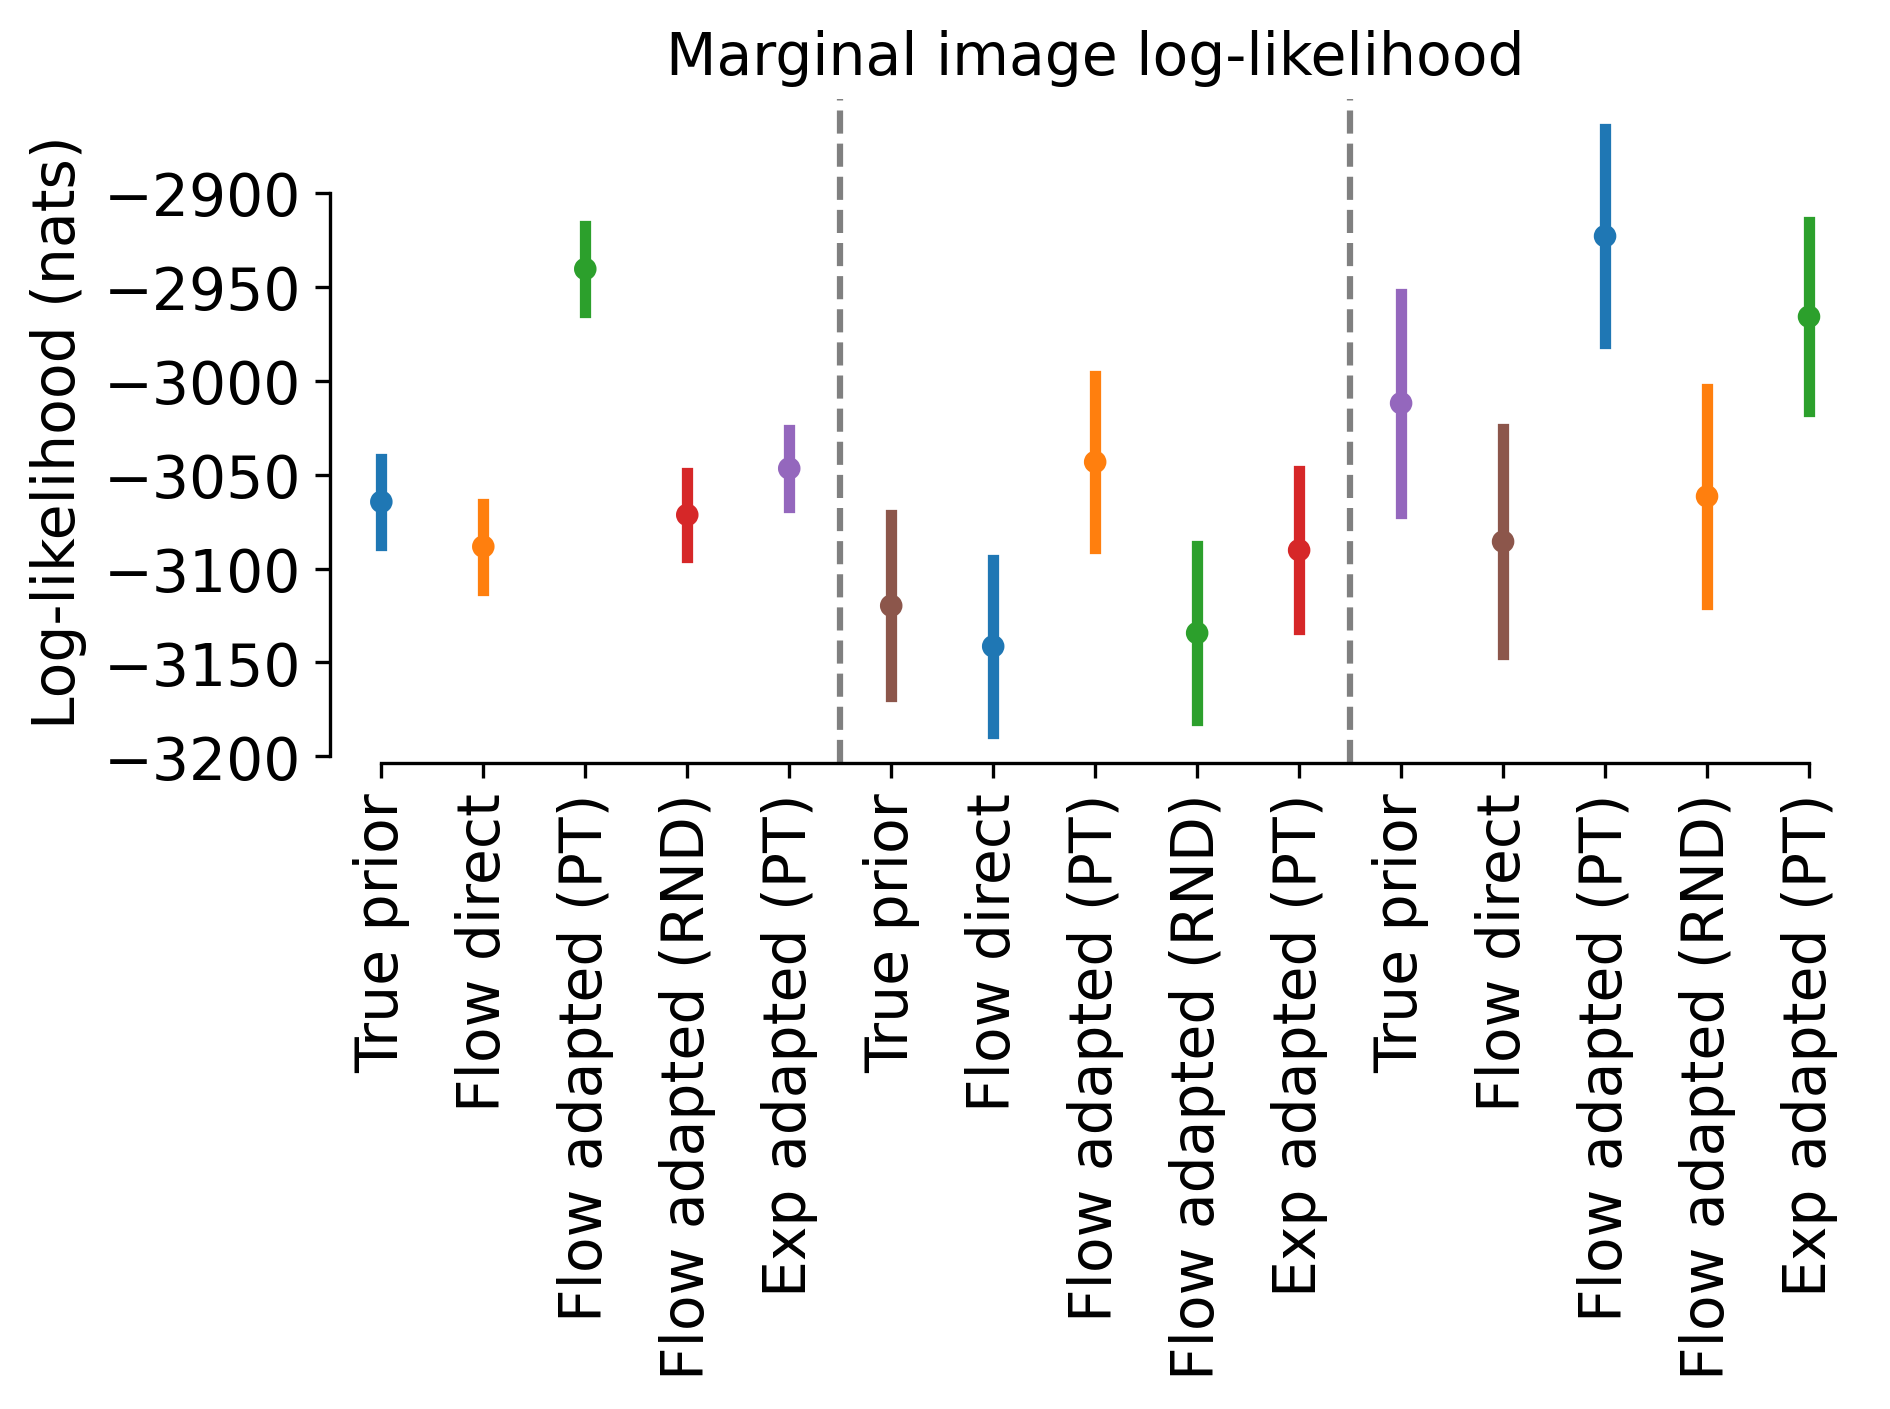

In [46]:
data = [
    true_logl_marg_train,
    direct_flow_logl_marg_train,
    pt_adpt_flow_logl_marg_train,
    rnd_adpt_flow_logl_marg_train,
    pt_exp_adpt_logl_marg_train,
    # rnd_exp_adpt_logl_marg_train,
    
    true_logl_marg_val,
    direct_flow_logl_marg_val,
    pt_adpt_flow_logl_marg_val,
    rnd_adpt_flow_logl_marg_val,
    pt_exp_adpt_logl_marg_val,
    # rnd_exp_adpt_logl_marg_val,
    
    true_logl_marg_test,
    direct_flow_logl_marg_test,
    pt_adpt_flow_logl_marg_test,
    rnd_adpt_flow_logl_marg_test,
    pt_exp_adpt_logl_marg_test,
    # rnd_exp_adpt_logl_marg_test,
]
labels = [
    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",

    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",
    
    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=6)
ax = sns.pointplot(data=data, ax=ax, errorbar="se", join=False, palette=palette, markers=".")
# add mean values
# for i, value in enumerate(data):
#     # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
#     # add a red dot
#     ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 5 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [16]:
data_dim = 0
device = "cuda"
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"

true_logl_prior_train, true_train_sem = compute_logl(
    model=true_prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_prior_val, true_val_sem = compute_logl(
    model=true_prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_prior_test, true_test_sem = compute_logl(
    model=true_prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

direct_flow_logl_prior_train, direct_flow_train_sem = compute_logl(
    model=direct_flow,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
direct_flow_logl_prior_val, direct_flow_val_sem = compute_logl(
    model=direct_flow,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
direct_flow_logl_prior_test, direct_flow_test_sem = compute_logl(
    model=direct_flow,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

pt_adpt_flow_logl_prior_train, pt_adpt_flow_train_sem = compute_logl(
    model=pt_adpt_flow.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_prior_val, pt_adpt_flow_val_sem = compute_logl(
    model=pt_adpt_flow.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_adpt_flow_logl_prior_test, pt_adpt_flow_test_sem = compute_logl(
    model=pt_adpt_flow.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

rnd_adpt_flow_logl_prior_train, rnd_adpt_flow_train_sem = compute_logl(
    model=rnd_adpt_flow.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_adpt_flow_logl_prior_val, rnd_adpt_flow_val_sem = compute_logl(
    model=rnd_adpt_flow.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_adpt_flow_logl_prior_test, rnd_adpt_flow_test_sem = compute_logl(
    model=rnd_adpt_flow.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

pt_exp_adpt_logl_prior_train, pt_exp_adpt_train_sem = compute_logl(
    model=pt_exp_adpt_prior.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_exp_adpt_logl_prior_val, pt_exp_adpt_val_sem = compute_logl(
    model=pt_exp_adpt_prior.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
pt_exp_adpt_logl_prior_test, pt_exp_adpt_test_sem = compute_logl(
    model=pt_exp_adpt_prior.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

rnd_exp_adpt_logl_prior_train, rnd_exp_adpt_train_sem = compute_logl(
    model=rnd_exp_adpt_prior.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_exp_adpt_logl_prior_val, rnd_exp_adpt_val_sem = compute_logl(
    model=rnd_exp_adpt_prior.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
rnd_exp_adpt_logl_prior_test, rnd_exp_adpt_test_sem = compute_logl(
    model=rnd_exp_adpt_prior.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

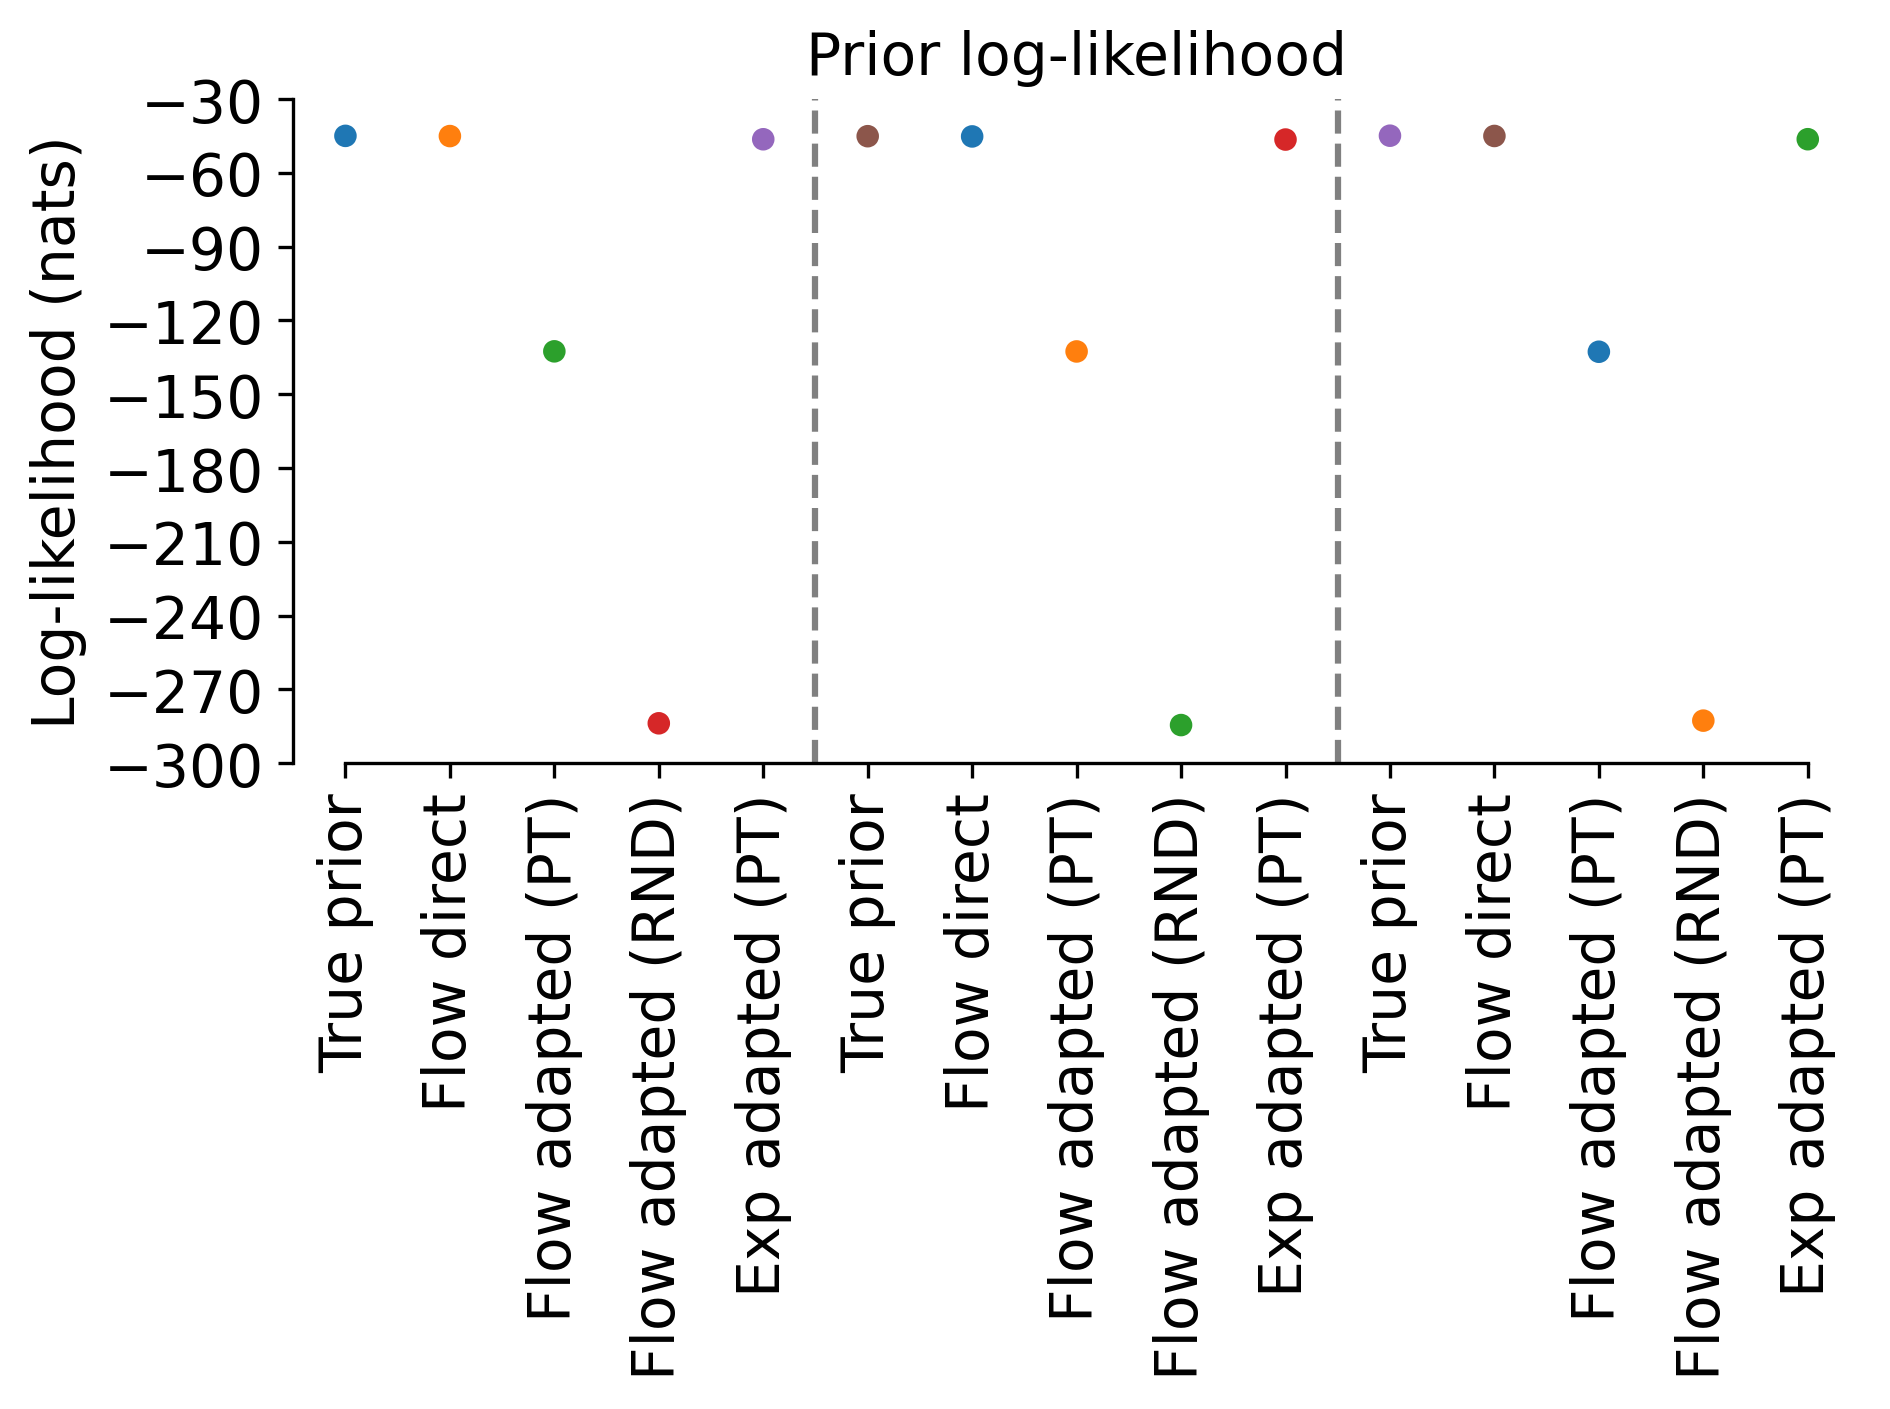

In [47]:
data = [
    true_logl_prior_train.detach().cpu(),
    direct_flow_logl_prior_train.detach().cpu(),
    pt_adpt_flow_logl_prior_train.detach().cpu(),
    rnd_adpt_flow_logl_prior_train.detach().cpu(),
    pt_exp_adpt_logl_prior_train.detach().cpu(),
    # rnd_exp_adpt_logl_prior_train.detach().cpu(),
    
    true_logl_prior_val.detach().cpu(),
    direct_flow_logl_prior_val.detach().cpu(),
    pt_adpt_flow_logl_prior_val.detach().cpu(),
    rnd_adpt_flow_logl_prior_val.detach().cpu(),
    pt_exp_adpt_logl_prior_val.detach().cpu(),
    # rnd_exp_adpt_logl_prior_val.detach().cpu(),

    true_logl_prior_test.detach().cpu(),
    direct_flow_logl_prior_test.detach().cpu(),
    pt_adpt_flow_logl_prior_test.detach().cpu(),
    rnd_adpt_flow_logl_prior_test.detach().cpu(),
    pt_exp_adpt_logl_prior_test.detach().cpu(),
    # rnd_exp_adpt_logl_prior_test.detach().cpu(),
]
labels = [
    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",
    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",
    "True prior",
    "Flow direct",
    "Flow adapted (PT)",
    "Flow adapted (RND)",
    "Exp adapted (PT)",
    # "Exp adapted (RND)",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=6)
ax = sns.pointplot(
    data=data, ax=ax, errorbar="se", join=False, palette=palette, markers="."
)
# add mean values
# for i, value in enumerate(data):
#     # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
#     # add a red dot
#     ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Prior log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 5 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")

ax.set_yticks(range(-300, 0, 30))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [35]:
from pathlib import Path


def visualize_marginal_flow(
    models,
    data_loader,
    device="cpu",
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=3,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="darkorange",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    **catch_all,
):
    all_responses = []
    for batch in data_loader:
        responses, _ = batch
        all_responses.append(responses.to(device))
    all_responses = torch.cat(all_responses, dim=0)
    n_dims_to_plot = len(dims_to_plot)
    with torch.no_grad():
        n_dims_all = all_responses.shape[1]
        x = (
            torch.linspace(density_support[0], density_support[1], density_n_samples)
            .repeat(n_dims_all, 1)
            .T
        )
        fig, axs = plt.subplots(
            7,
            7,
            sharey=True,
            dpi=fig_dpi,
        )
        for idx, ax in zip(dims_to_plot, axs.ravel()):
            sns.histplot(
                all_responses[:, idx].detach().cpu(),
                ax=ax,
                stat="density",
                element="step",
                color=data_color,
                alpha=data_alpha,
                label="Data",
            )
        colors = sns.color_palette("tab10", n_colors=len(models))
        for model, color, label, linestyle in zip(
            models, colors, catch_all["labels"], catch_all["linestyles"]
        ):
            flow_density = model.factorized_log_prob(x.to(device)).exp().cpu().numpy()
            print(flow_density.shape)
            for idx, ax in zip(dims_to_plot, axs.ravel()):
                ax.plot(
                    x[:, idx].detach().cpu(),
                    flow_density[:, idx],
                    linewidth=linewidth,
                    color=color,
                    label=label,
                    linestyle=linestyle,
                )
                ax.set_xlim(*plot_xlim)
                ax.set_ylim(*plot_ylim)
                ax.axis("off")
            # ax.tick_params(axis="both", which="both", labelsize=fontsize)
            # ax.set_ylabel("$p(x)$", fontsize=fontsize)
            # ax.set_xlabel("x", fontsize=fontsize)
            for ax in axs.ravel()[n_dims_to_plot:]:
                ax.axis("off")
        handles, labels = axs.flatten()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower right", fontsize=fontsize)
        fig.savefig(
            fig_save_dir / catch_all["fig_name"],
            bbox_inches="tight",
            transparent=True,
        )
        # close the figure to avoid memory leak
        plt.close(fig)

In [37]:
visualize_marginal_flow(
    models=[true_prior, direct_flow, pt_adpt_flow.prior, rnd_adpt_flow.prior, pt_exp_adpt_prior.prior, rnd_exp_adpt_prior.prior],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=1,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="lightpink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="marginal_flow.pdf",
    labels=["True prior", "Flow direct", "Flow adapted (PT)", "Flow adapted (RND)", "Exp adapted (PT)", "Exp adapted (RND)"],
    linestyles=["-", "--", "-.", ":", "-", "--"]
)

(1000, 45)
(1000, 45)
(1000, 45)
(1000, 45)
(1000, 45)
(1000, 45)


In [39]:
visualize_marginal_flow(
    models=[pt_adpt_flow.prior, rnd_adpt_flow.prior, pt_exp_adpt_prior.prior],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=1,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="lightpink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="flow_priors.pdf",
    labels=[
        "Flow adapted (PT)",
        "Flow adapted (RND)",
    ],
    linestyles=["-", "--"],
)

(1000, 45)
(1000, 45)


In [40]:
visualize_marginal_flow(
    models=[
        pt_exp_adpt_prior.prior, 
        rnd_exp_adpt_prior.prior
    ],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=1,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="lightpink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="exp_priors.pdf",
    labels=[
        "Exp adapted (PT)",
        "Exp adapted (RND)",
    ],
    linestyles=["-", "--"],
)

(1000, 45)
(1000, 45)


In [ ]:
adapted_prior = (AdaptPriorResult & restrictions).fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [ ]:
adapted_prior_model = torch.load(adapted_prior["model"], map_location="cpu")

In [ ]:

adapted_prior_exp = (AdaptPriorResult & restrictions).fetch(
    download_path="/tmp",
    order_by="val_marginal_obs_ll_mean DESC",
    limit=1,
    as_dict=True,
)[0]

In [ ]:
download_path = "/tmp"
criterion = "val_ll_mean"
k = 1

trained_prior_restriction = (
    f"dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
)
prior_result_table = FlowPriorResult & trained_prior_restriction

dataloader_restrictions = (
    f"data_fname = '/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl'"
)
dataloader_table = DataLoaderConfig & dataloader_restrictions

prior_config_proj_col = "fp_id"
best_val_prior_results = fetch_best_model_results(
    result_table=prior_result_table,
    config_table=FlowPriorConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=FPTrainerConfig,
    config_proj_col=prior_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
prior_model = torch.load(best_val_prior_results["model"], map_location="cpu")

# get likelihood model for marginal likelihood
likelihood_config_proj_col = "ll_id"
likelihood_restrictions = restriction = "dl_id = 'b8379e7d6998fc94a08a9a3742eec12d'"
likelihood_result_table = LikelihoodResult & likelihood_restrictions

best_val_likelihood_results = fetch_best_model_results(
    result_table=likelihood_result_table,
    config_table=LikelihoodConfig,
    data_loader_config_table=dataloader_table,
    trainer_config_table=LLTrainerConfig,
    config_proj_col=likelihood_config_proj_col,
    criterion=criterion,
    k=k,
    download_path=download_path,
)
likelihood_model = torch.load(best_val_likelihood_results["model"], map_location="cpu")

dataloader_args = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_args["data_fname"],
    train_prop=dataloader_args["train_prop"],
    val_prop=dataloader_args["val_prop"],
    batch_size=128,
)

joint_model = G.Joint(prior=prior_model, conditional=likelihood_model)

In [ ]:
true_prior = G.IndependentExponential(rate=torch.ones(45))

In [ ]:
data_dim = 1
cond_dim = 0
mc_sample_size = 10_000
device = "cpu"
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"
true_logl_marg_train, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_val, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_logl_marg_test, _ = compute_logl_marginal(
    conditional=likelihood_model,
    prior=true_prior,
    mc_sample_size=mc_sample_size,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [ ]:
true_data_logl_marg_train, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=train_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_val, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=val_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_data_logl_marg_test, _ = compute_logl_data_marginal(
    conditional_model=likelihood_model,
    data_loader=test_loader,
    data_dim=data_dim,
    cond_dim=cond_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [ ]:
logl_mc_marg_task_train, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_task_val, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_task_test, _ = logl_mc_marginal_eval(
    joint_model=joint_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [ ]:
logl_mc_marg_adpt_train, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=train_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_val, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=val_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
logl_mc_marg_adpt_test, _ = logl_mc_marginal_eval(
    joint_model=adapted_prior_model,
    data_loader=test_loader,
    data_dim=data_dim,
    mc_sample_size=mc_sample_size,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

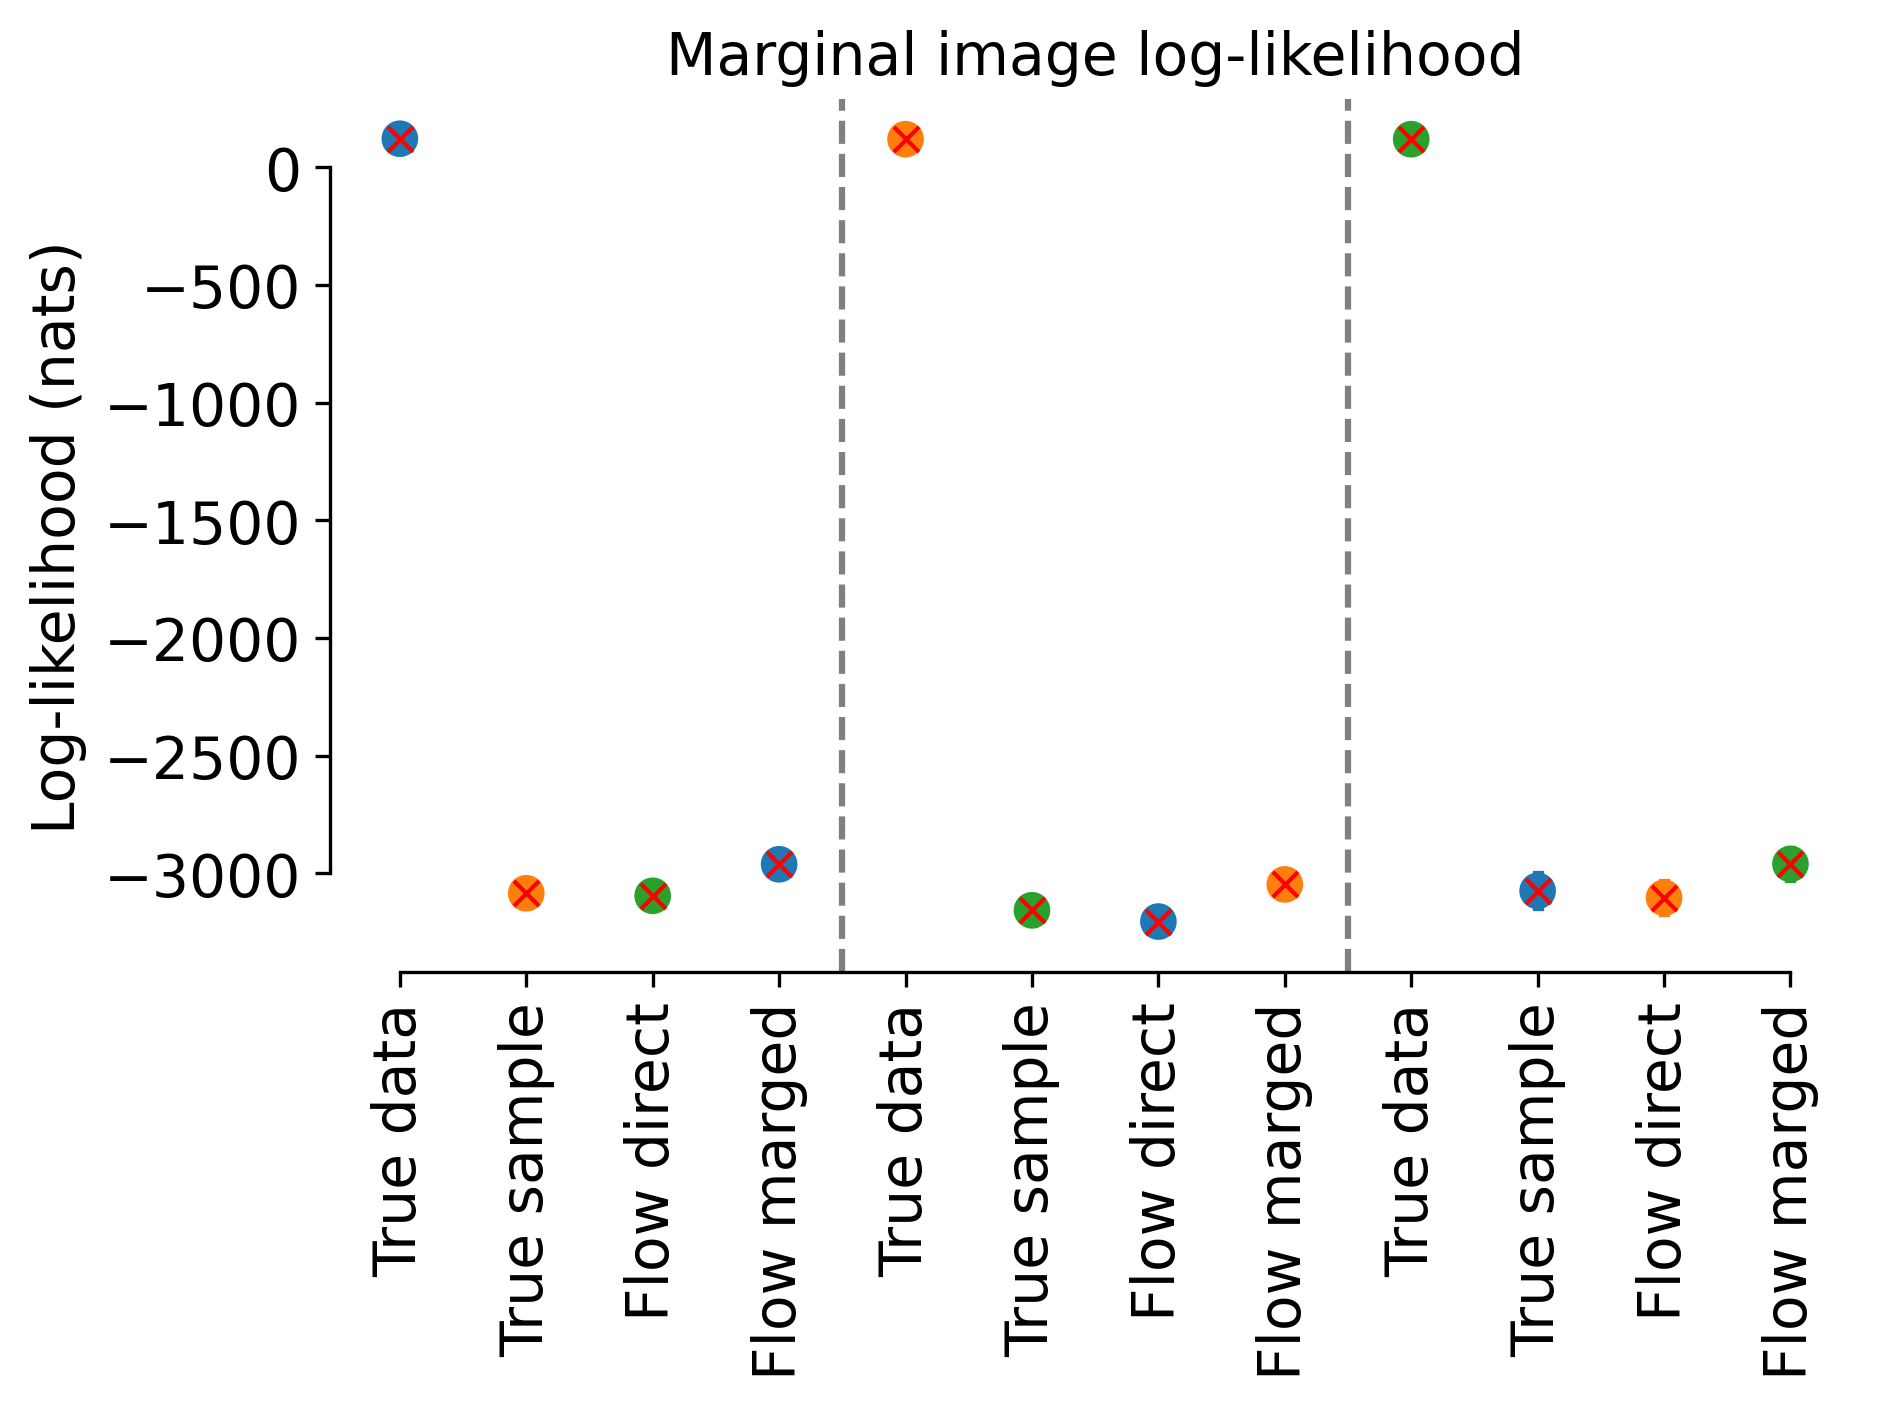

In [ ]:
data = [
    true_data_logl_marg_train.detach(),
    true_logl_marg_train.detach(),
    logl_mc_marg_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),
    true_data_logl_marg_val.detach(),
    true_logl_marg_val.detach(),
    logl_mc_marg_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),
    true_data_logl_marg_test.detach(),
    true_logl_marg_test.detach(),
    logl_mc_marg_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True data",
    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 4 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

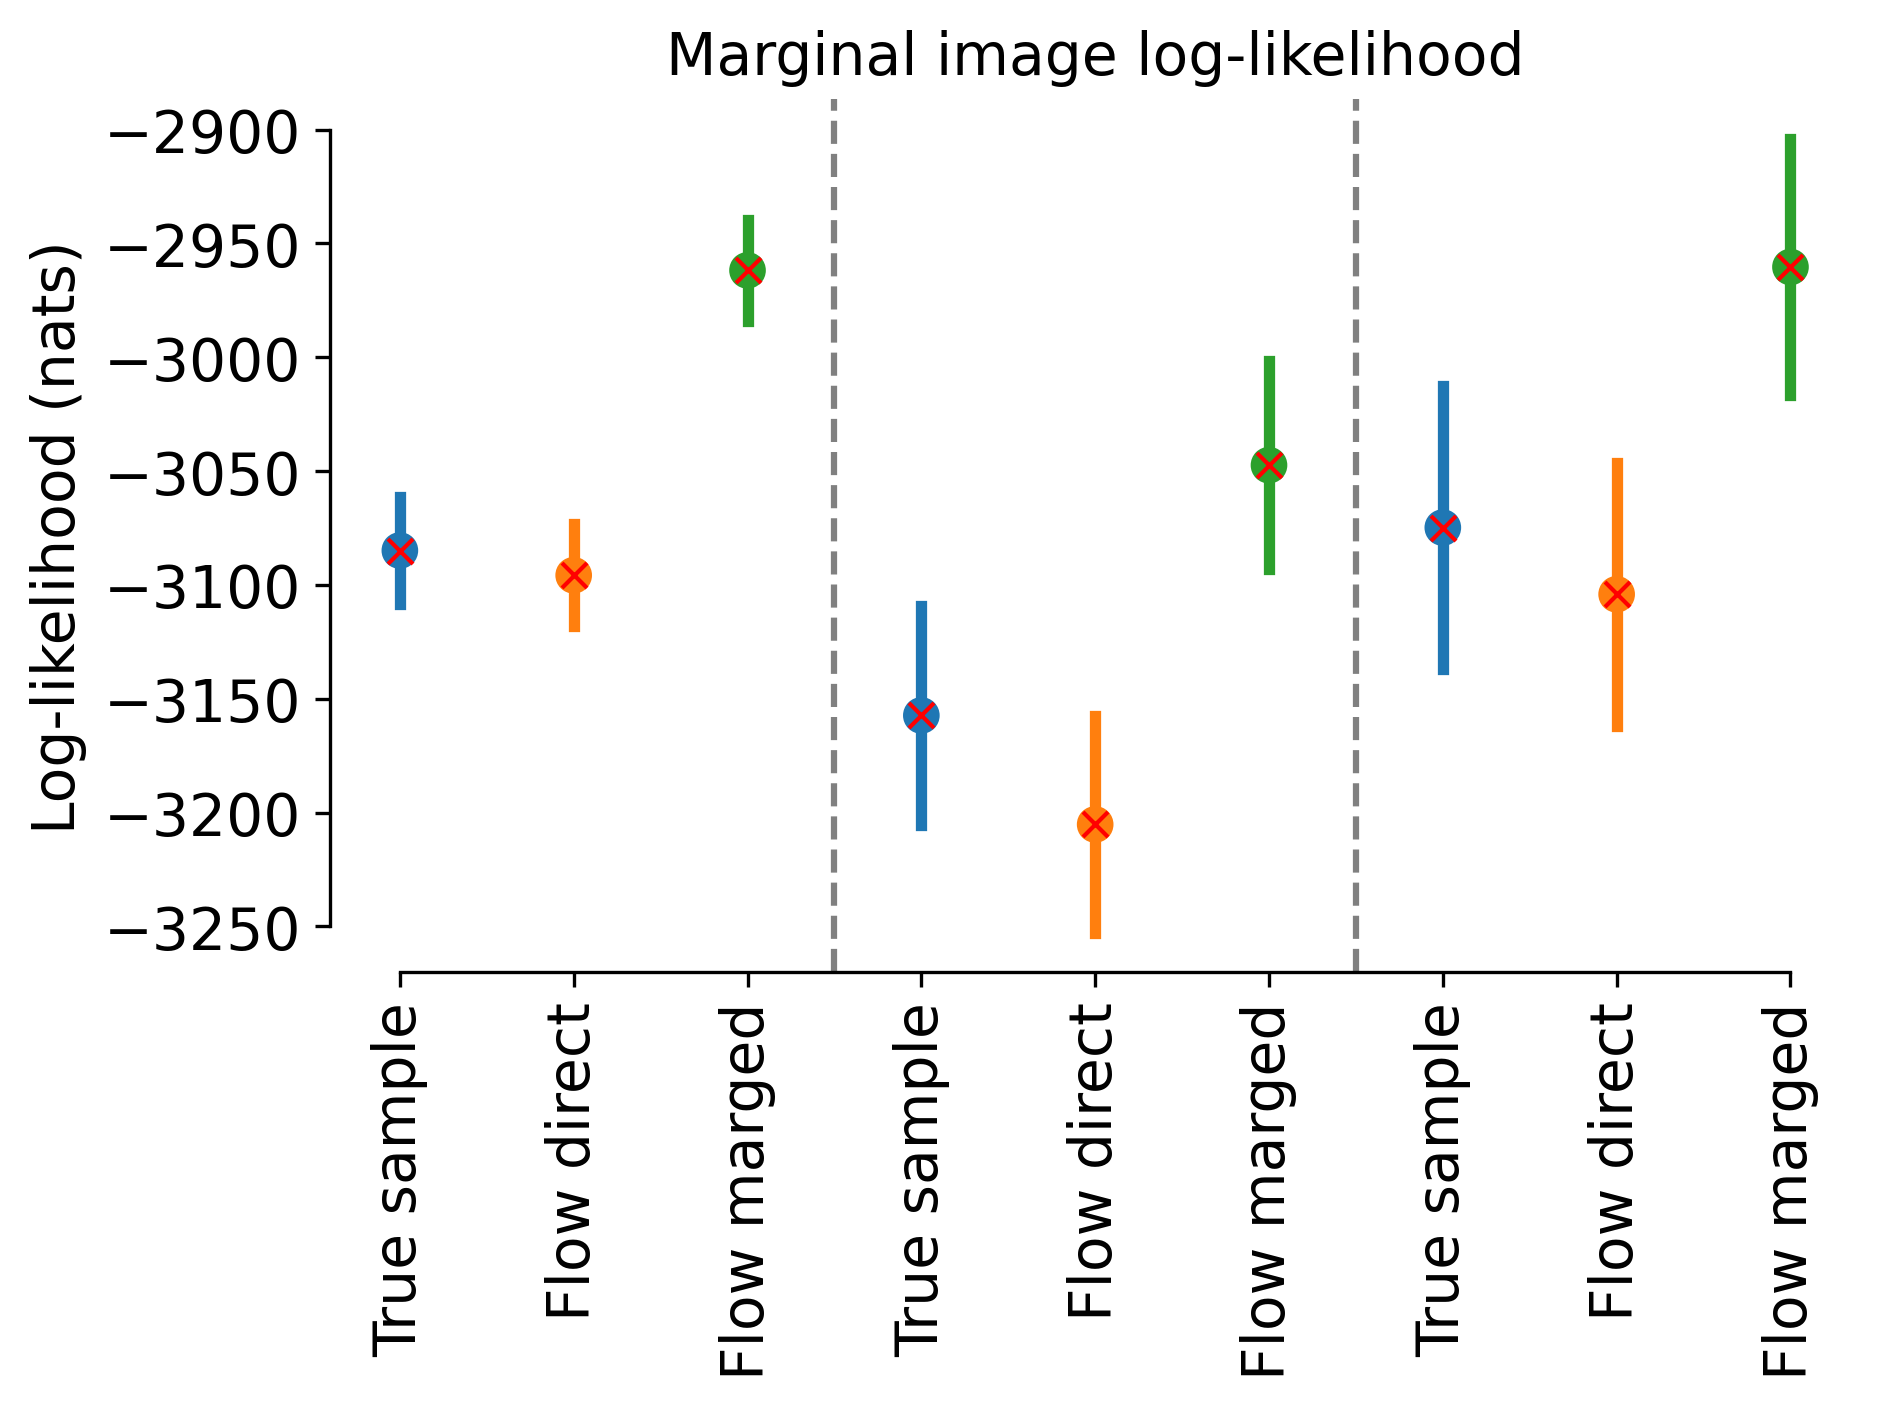

In [ ]:
data = [
    true_logl_marg_train.detach(),
    logl_mc_marg_task_train.detach(),
    logl_mc_marg_adpt_train.detach(),
    true_logl_marg_val.detach(),
    logl_mc_marg_task_val.detach(),
    logl_mc_marg_adpt_val.detach(),
    true_logl_marg_test.detach(),
    logl_mc_marg_task_test.detach(),
    logl_mc_marg_adpt_test.detach(),
]
labels = [
    "True sample",
    "Flow direct",
    "Flow marged",
    "True sample",
    "Flow direct",
    "Flow marged",
    "True sample",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Marginal image log-likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [ ]:
data_dim = 0
device = torch.device("cuda:1")
reduction = "none"
uncertainty = "sem"
normalize = "none"
unit = "nats"

true_train_prior_lp, true_train_sem = compute_logl(
    model=true_prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_val_prior_lp, true_val_sem = compute_logl(
    model=true_prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
true_test_prior_lp, true_test_sem = compute_logl(
    model=true_prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [ ]:
model_train_prior_lp, true_train_sem = compute_logl(
    model=prior_model,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
model_val_prior_lp, true_val_sem = compute_logl(
    model=prior_model,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
model_test_prior_lp, true_test_sem = compute_logl(
    model=prior_model,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)


In [ ]:
adapted_model_train_prior_lp, true_train_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=train_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
adapted_model_val_prior_lp, true_val_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=val_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)
adapted_model_test_prior_lp, true_test_sem = compute_logl(
    model=adapted_prior_model.prior,
    data_loader=test_loader,
    data_dim=data_dim,
    device=device,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

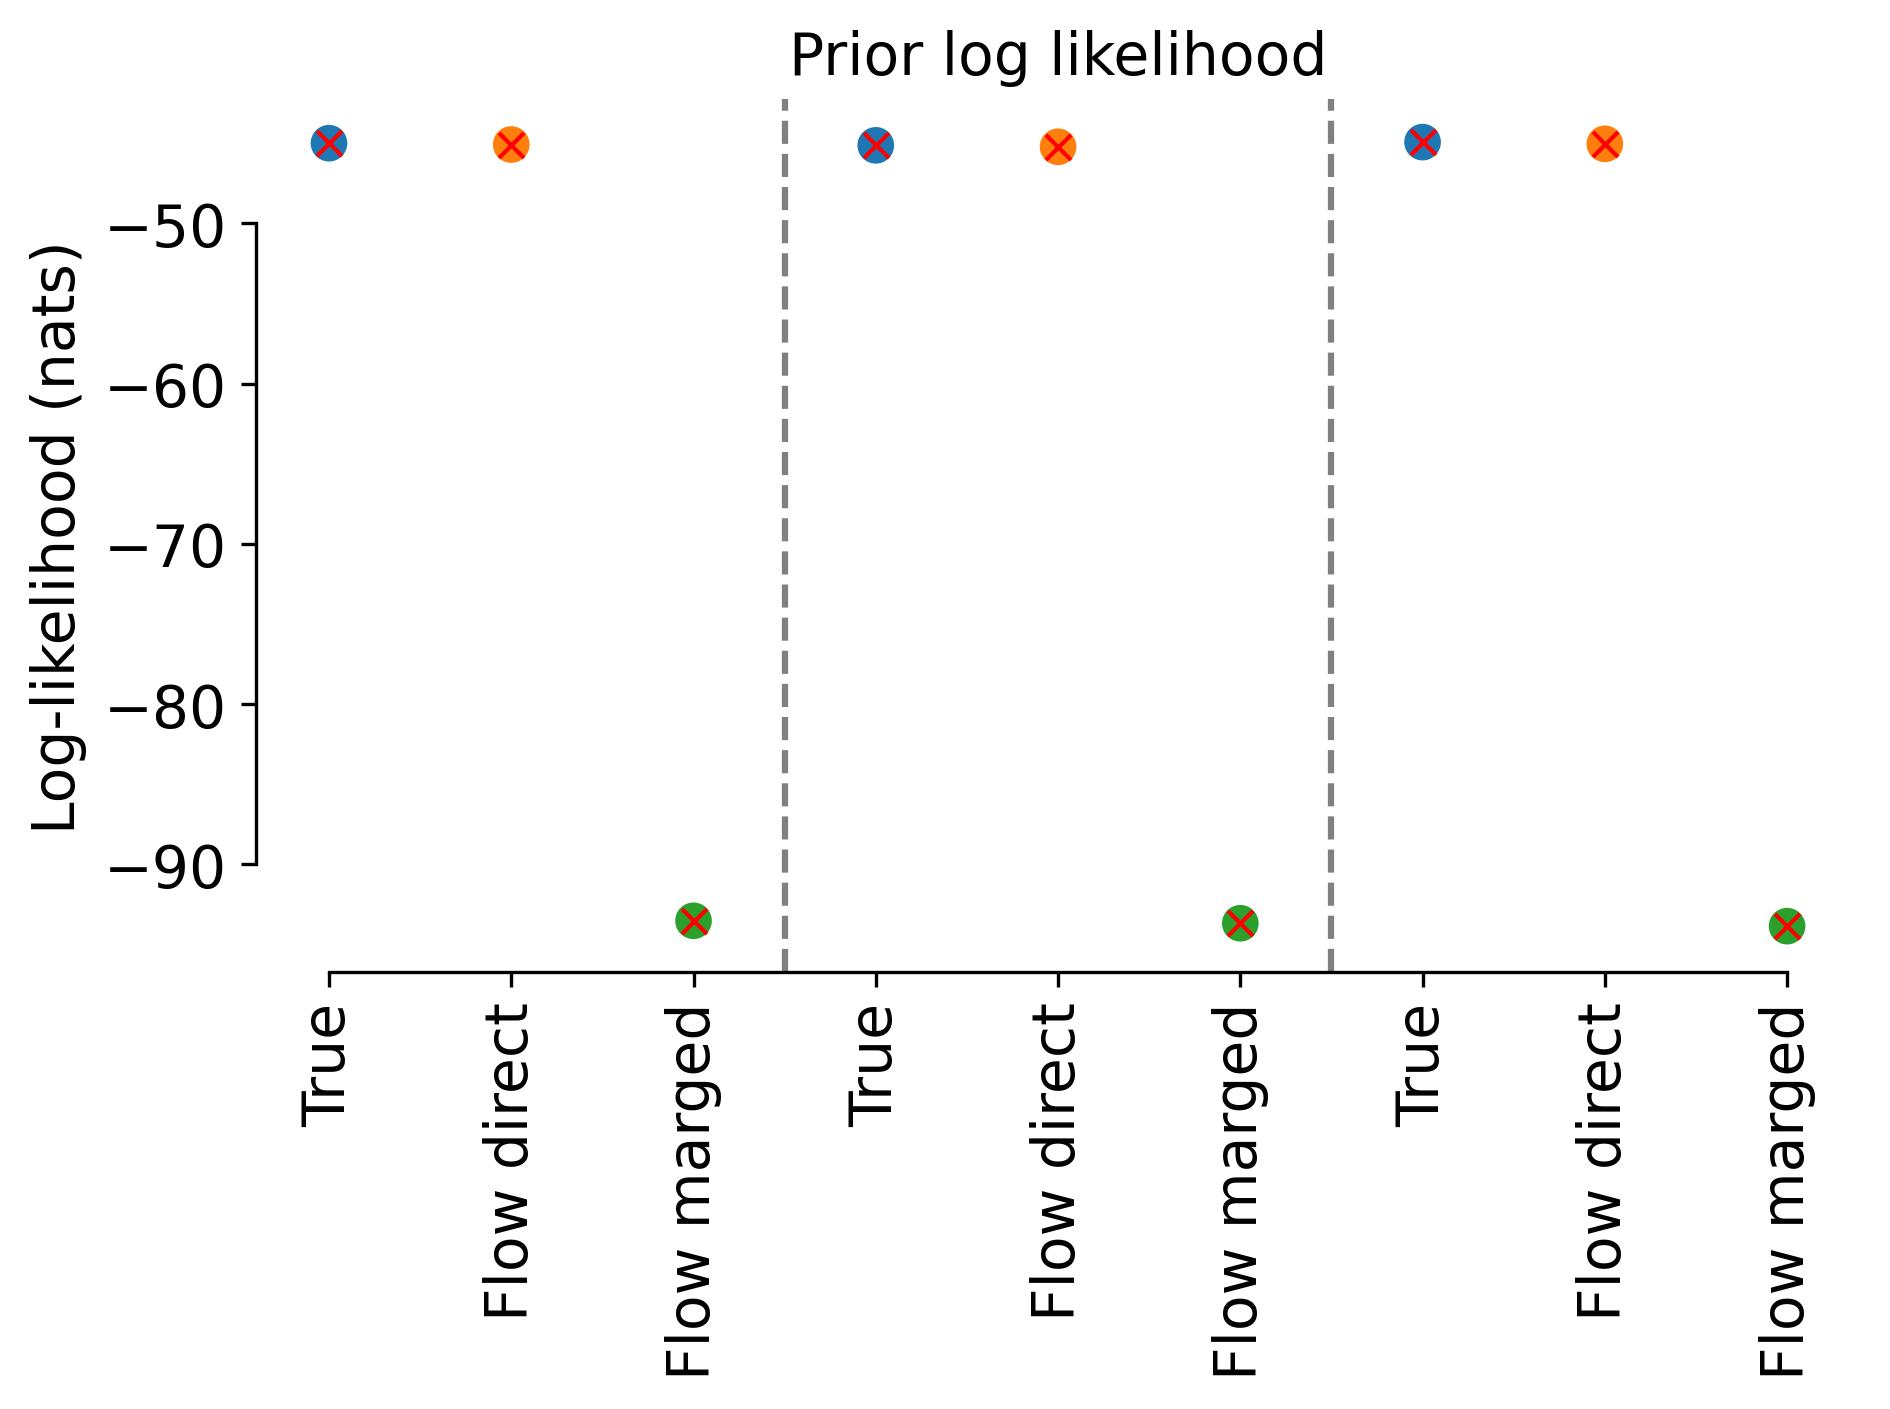

In [ ]:
data = [
    true_train_prior_lp.detach().cpu(),
    model_train_prior_lp.detach().cpu(),
    adapted_model_train_prior_lp.detach().cpu(),
    true_val_prior_lp.detach().cpu(),
    model_val_prior_lp.detach().cpu(),
    adapted_model_val_prior_lp.detach().cpu(),
    true_test_prior_lp.detach().cpu(),
    model_test_prior_lp.detach().cpu(),
    adapted_model_test_prior_lp.detach().cpu(),
]
labels = [
    "True",
    "Flow direct",
    "Flow marged",
    "True",
    "Flow direct",
    "Flow marged",
    "True",
    "Flow direct",
    "Flow marged",
]
# Creating a boxplot
fig, ax = plt.subplots(dpi=300)
# set two colors as palette and cycle
palette = sns.color_palette("tab10", n_colors=3)
ax = sns.pointplot(data=data, ax=ax, palette=palette, errorbar="se")
# add mean values
for i, value in enumerate(data):
    # ax.text(i + 0.3, value.mean() + 0.5, f"{value.mean():.2f}", ha="center", va="bottom", fontsize=8)
    # add a red dot
    ax.plot(i, value.mean(), "rx")
ax.set_xticklabels(labels, rotation=90)
ax.set_title("Prior log likelihood", fontsize=14)
ax.set_ylabel("Log-likelihood (nats)", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
for tick in range(len(labels)):
    if tick % 3 == 0 and tick != 0:
        ax.axvline(tick - 0.5, ls="--", color="grey")
# ax.set_yticks(range(-100, 0, 10))
sns.despine(ax=ax, trim=True)
plt.tight_layout()

# # Display the plot
# plt.show()

In [ ]:
from pathlib import Path

def visualize_marginal_flow(
    models,
    data_loader,
    device="cpu",
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=3,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="darkorange",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    **catch_all,
):
    all_responses = []
    for batch in data_loader:
        responses, _ = batch
        all_responses.append(responses.to(device))
    all_responses = torch.cat(all_responses, dim=0)
    n_dims_to_plot = len(dims_to_plot)
    with torch.no_grad():
        n_dims_all = all_responses.shape[1]
        x = (
            torch.linspace(density_support[0], density_support[1], density_n_samples)
            .repeat(n_dims_all, 1)
            .T
        )
        fig, axs = plt.subplots(
            7,
            7,
            sharey=True,
            dpi=fig_dpi,
        )
        for idx, ax in zip(dims_to_plot, axs.ravel()):
            sns.histplot(
                all_responses[:, idx].detach().cpu(),
                ax=ax,
                stat="density",
                element="step",
                color=data_color,
                alpha=data_alpha,
                label="Data",
            )
        colors = sns.color_palette("tab10", n_colors=len(models))
        for model, color, label, linestyle in zip(models, colors, catch_all['labels'], catch_all["linestyles"]):
            flow_density = model.factorized_log_prob(x.to(device)).exp().cpu().numpy()
            print(flow_density.shape)
            for idx, ax in zip(dims_to_plot, axs.ravel()):
                ax.plot(
                    x[:, idx].detach().cpu(),
                    flow_density[:, idx],
                    linewidth=linewidth,
                    color=color,
                    label=label,
                    linestyle=linestyle,
                )
                ax.set_xlim(*plot_xlim)
                ax.set_ylim(*plot_ylim)
                ax.axis("off")
            # ax.tick_params(axis="both", which="both", labelsize=fontsize)
            # ax.set_ylabel("$p(x)$", fontsize=fontsize)
            # ax.set_xlabel("x", fontsize=fontsize)
            for ax in axs.ravel()[n_dims_to_plot:]:
                ax.axis("off")
        handles, labels = axs.flatten()[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower right", fontsize=fontsize)
        fig.savefig(
            fig_save_dir / catch_all["fig_name"],
            bbox_inches="tight",
            transparent=True,
        )
        # close the figure to avoid memory leak
        plt.close(fig)

In [ ]:
visualize_marginal_flow(
    models=[true_prior, prior_model, adapted_prior_model.prior],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=2,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="lightpink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="marginal_flow.pdf",
    labels=["True", "Flow direct", "Flow marged"],
    linestyles=["-", "--", "dotted"],
)

(1000, 45)
(1000, 45)
(1000, 45)


In [ ]:
visualize_marginal_flow(
    models=[true_prior, prior_model],
    data_loader=val_loader,
    device=device,
    density_support=(1e-3, 10),
    density_n_samples=1000,
    dims_to_plot=range(45),
    fig_dpi=300,
    linewidth=3,
    fontsize=10,
    plot_xlim=(0, 7),
    plot_ylim=(0, 1),
    data_color="pink",
    data_alpha=0.4,
    fig_save_dir=Path("/src/project/figures/learning/"),
    fig_name="twoflows.pdf",
    labels=["True", "Flow"],
)

(1000, 45)
(1000, 45)
